In [ ]:
## Ex. No .03
## DL-Convolutional Deep Neural Network for Image Classification
## Reg.No: 212223100032
## Name: Mario Viofer J

In [ ]:
import torch as t
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# Step 1: Load and Preprocess Data
## Define transformations for images

In [ ]:
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
train_data=torchvision.datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_data=torchvision.datasets.MNIST(root='./data',train=False,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 50.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.02MB/s]


In [ ]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [ ]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

## Create DataLoader for batch processing

In [ ]:
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

# Step 2: Generate the classifier model

In [ ]:
class CNNClassifier(nn.Module):
  def __init__(self):
    super(CNNClassifier,self).__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)

    # UPDATE THIS LINE AFTER YOU SEND ME IMAGE SIZE
    self.fc1 = nn.Linear(128 * 3 * 3, 128)

    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.pool(t.relu(self.conv1(x)))
    x = self.pool(t.relu(self.conv2(x)))
    x = self.pool(t.relu(self.conv3(x)))

    x = x.view(x.size(0), -1)   # <-- IMPORTANT FIX

    x = nn.functional.relu(self.fc1(x))
    x = nn.functional.relu(self.fc2(x))
    x = self.fc3(x)
    return x


## Initialize modeland move model to GPU if available

In [ ]:
from torchsummary import summary
model=CNNClassifier()
if t.cuda.is_available():
  device=t.device("cuda")
  model.to(device)
  summary(model,input_size=(1,28,28))

## Initialize model, loss function, and optimizer

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

# Step 3: Train the Model

In [ ]:
def train_model(model,train_loader,num_epochs):
  for epoch in range(num_epochs):
    model.train()
    running_loss=0.0
    for images,labels in train_loader:
      if t.cuda.is_available():
        images,labels=images.to(device),labels.to(device)
      optimizer.zero_grad()
      outputs=model(images)
      loss=criterion(outputs,labels)
      loss.backward()
      optimizer.step()
      running_loss+=loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [ ]:
train_model(model,train_loader,num_epochs=10)

Epoch [1/10], Loss: 0.1247
Epoch [2/10], Loss: 0.0497
Epoch [3/10], Loss: 0.0363
Epoch [4/10], Loss: 0.0281
Epoch [5/10], Loss: 0.0263
Epoch [6/10], Loss: 0.0212
Epoch [7/10], Loss: 0.0200
Epoch [8/10], Loss: 0.0180
Epoch [9/10], Loss: 0.0170
Epoch [10/10], Loss: 0.0145


# Step 4: Test the Model

Test Accuracy: 0.9888


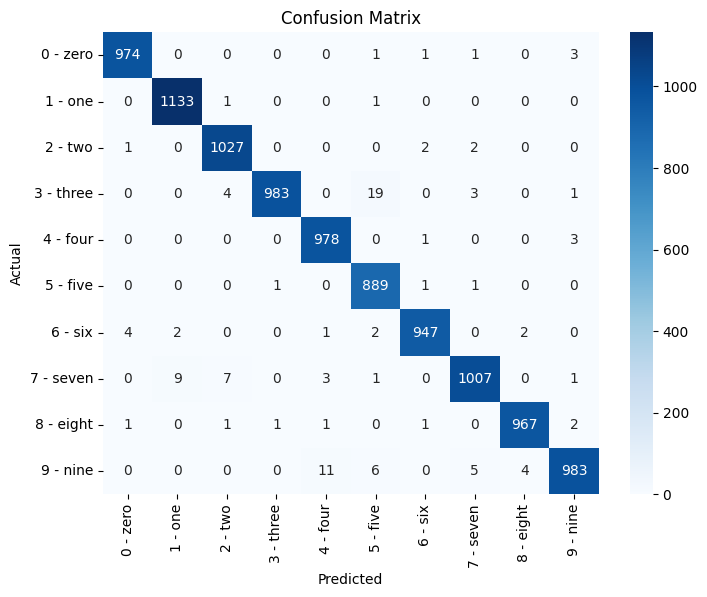

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.97      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.97      1.00      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
def test_model(model, test_loader):
  model.eval()
  correct = 0
  total = 0
  all_preds = []
  all_labels = []
  with t.no_grad():
    for images, labels in test_loader:
      if t.cuda.is_available():
        images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      _, predicted = t.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
  accuracy = correct/total
  print(f"Test Accuracy: {accuracy:.4f}")
  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_data.classes, yticklabels=test_data.classes)
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title("Confusion Matrix")
  plt.show()
  print("Classification Report:")
  print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))
test_model(model, test_loader)


# Step 5: Predict on a Single Image

In [ ]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    if t.cuda.is_available():
        image = image.to(device)

    with t.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = t.max(output, 1)

    class_names = [str(i) for i in range(10)]
    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')

## Example Prediction

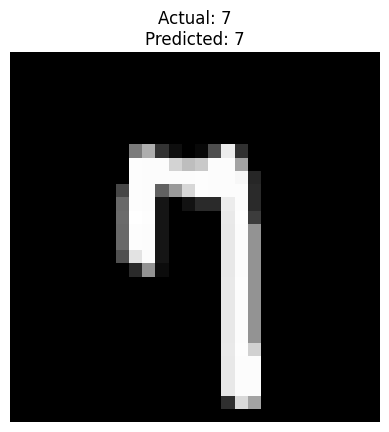

Actual: 7, Predicted: 7


In [ ]:
predict_image(model, image_index=80, dataset=test_data)